# YBS 4. Sınıf Python ile Veri Bilimi: Dönem Sonu Projesi
## Konu: E-Ticaret Sahtekarlık (Fraud) Tespiti ve Maliyet-Duyarlı Karar Optimizasyonu
**Yazar:** Selim Gök  
**Ders:** Python ile Veri Bilimi (YBS Dönem Sonu Projesi)  
**Tarih:** 21 Haziran 2026

---

### Projenin Amacı ve İş Senaryosu
Geleneksel makine öğrenmesi modelleri genellikle doğruluk (accuracy) veya F1 skoru gibi saf istatistiksel metrikleri maksimize etmeye odaklanır. Ancak bir işletme perspektifinden bakıldığında, tüm sınıflandırma hatalarının maliyeti aynı değildir.

E-Ticaret sahtekarlık (fraud) tespitinde, sahte bir işlemi kaçırmak (False Negative) ile meşru bir müşteriyi yanlışlıkla engellemek (False Positive - müşteri sürtünmesi) çok farklı finansal sonuçlar doğurur:
- **Kaçırılan Sahtekarlık (FN):** Şirket doğrudan finansal kayıp (chargeback / ters ibraz maliyeti + ürün kaybı) yaşar.
- **Yanlış Engelleme (FP):** Müşteri memnuniyeti kaybı ve yaşam boyu değer düşüşüyle karşı karşıya kalınır.

Bu projede, Kaggle'dan alınan iki ayrı veri seti birleştirilerek (Data Fusion), iş mantığına dayalı en az 3 yeni değişken (Feature Engineering) türetilmiş, üç farklı sınıflandırma modeli (Lojistik Regresyon, Karar Ağacı, Rastgele Orman) eğitilmiş, SHAP analizi ile kararlar açıklanmış ve son aşamada, şirketin toplam finansal kaybını en aza indiren olasılık karar eşiği (decision threshold) simüle edilerek net ROI (Yatırım Getirisi) hesaplanmıştır.

### Kütüphanelerin Yüklenmesi ve Ayarlar

In [1]:
import os
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import shap
from fpdf import FPDF

# Grafik Stili Tanımlama
def set_antigravity_style():
    sns.set_theme(style="whitegrid", rc={
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#FFFFFF",
        "grid.color": "#F7FAFC",
        "grid.linewidth": 1.0,
        "text.color": "#1A365D",
        "axes.labelcolor": "#1A365D",
        "xtick.color": "#1A365D",
        "ytick.color": "#1A365D",
        "font.family": "sans-serif"
    })
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1A365D', '#1C4532', '#4A5568', '#718096'])

set_antigravity_style()
print("Kütüphaneler ve minimalist tasarım stili yüklendi.")

Kütüphaneler ve minimalist tasarım stili yüklendi.


### Adım 1: Veri Harmanlama (Data Fusion) ve Entegrasyonu
Kaggle'dan temin edilmiş iki ayrı veri setini kullanıyoruz:
1. `Fraud_Data.csv`: Kullanıcı işlemleri, üyelik tarihleri, cihaz kimlikleri ve sahtekarlık etiketleri (151,112 satır).
2. `IpAddress_to_Country.csv`: IP adres aralıklarının hangi ülkeye ait olduğunu gösteren coğrafi referans tablosu (138,846 satır).

Bu iki tabloyu sayısal IP adresleri üzerinden aralık eşleştirmesi yaparak sol birleşim (left join) mantığıyla entegre edeceğiz. Performans açısından Numpy'ın binary search (`searchsorted`) fonksiyonunu kullanıyoruz.

In [2]:
# Verileri indirme
files = {
    'Fraud_Data.csv': 'https://raw.githubusercontent.com/bruno-raffa/Fraud-Detection/master/Fraud_Data.csv',
    'IpAddress_to_Country.csv': 'https://raw.githubusercontent.com/bruno-raffa/Fraud-Detection/master/IpAddress_to_Country.csv'
}

print("Veri setleri indiriliyor / kontrol ediliyor...")
for filename, url in files.items():
    if not os.path.exists(filename):
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response:
            with open(filename, 'wb') as f:
                f.write(response.read())
        print(f"  -> {filename} başarıyla indirildi.")
    else:
        print(f"  -> {filename} zaten mevcut.")

# Verileri yükleme ve hızlı aralık birleştirme (Data Fusion)
print("Veriler yükleniyor...")
df_fraud = pd.read_csv('Fraud_Data.csv')
df_ip = pd.read_csv('IpAddress_to_Country.csv')

print("IP adresleri ülkelerle eşleştiriliyor...")
t0 = time.time()
df_ip = df_ip.sort_values('lower_bound_ip_address')
lowers = df_ip['lower_bound_ip_address'].values
uppers = df_ip['upper_bound_ip_address'].values
countries = df_ip['country'].values

ips = df_fraud['ip_address'].values
indices = np.searchsorted(lowers, ips, side='right') - 1

valid = (indices >= 0) & (indices < len(uppers))
matched_countries = np.where(
    valid & (ips <= uppers[indices]),
    countries[indices],
    'Unknown'
)
df_fraud['country'] = matched_countries
print(f"Birleştirme tamamlandı! Süre: {time.time() - t0:.4f} saniye.")
df_fraud.head()

Veri setleri indiriliyor / kontrol ediliyor...
  -> Fraud_Data.csv zaten mevcut.
  -> IpAddress_to_Country.csv zaten mevcut.
Veriler yükleniyor...
IP adresleri ülkelerle eşleştiriliyor...
Birleştirme tamamlandı! Süre: 0.0278 saniye.


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,country
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,Japan
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,United States
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,United States
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,Unknown
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,United States


### Adım 2: İş Mantığına Dayalı Özellik Mühendisliği (Feature Engineering)
Veri setindeki ham sütunların dışına çıkarak işletme risk senaryosuna göre 3 yeni özellik üretiyoruz:
1. `time_diff`: Kullanıcının kayıt olma zamanı ile satın alma zamanı arasındaki saniye farkı. Bot veya otomatik saldırı araçları kaydolduktan saniyeler sonra işlem yapar.
2. `device_user_count`: Aynı fiziksel cihazın (device_id) kaç farklı kullanıcı hesabı tarafından paylaşıldığı. Çalıntı kart denemeleri için cihaz paylaşımı yüksek bir risk bayrağıdır.
3. `ip_user_count`: Aynı IP adresinin kaç tekil kullanıcı tarafından kullanıldığı. Proxy/VPN kullanımlarını yakalamada etkilidir.

In [3]:
print("Özellik mühendisliği uygulanıyor...")
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

# 1. time_diff
df_fraud['time_diff'] = (df_fraud['purchase_time'] - df_fraud['signup_time']).dt.total_seconds()

# 2. device_user_count
df_fraud['device_user_count'] = df_fraud.groupby('device_id')['user_id'].transform('count')

# 3. ip_user_count
df_fraud['ip_user_count'] = df_fraud.groupby('ip_address')['user_id'].transform('count')

# Ek özellikler
df_fraud['purchase_hour'] = df_fraud['purchase_time'].dt.hour
df_fraud['purchase_day_of_week'] = df_fraud['purchase_time'].dt.dayofweek

print("Yeni özellikler başarıyla türetildi.")
df_fraud[['time_diff', 'device_user_count', 'ip_user_count']].describe()

Özellik mühendisliği uygulanıyor...
Yeni özellikler başarıyla türetildi.


,time_diff,device_user_count,ip_user_count
count,1.511120e+05,151112.000000,151112.000000
mean,4.932029e+06,1.684367,1.602719
std,3.126263e+06,2.616954,2.596240
min,1.000000e+00,1.000000,1.000000
25%,2.186754e+06,1.000000,1.000000
50%,4.926346e+06,1.000000,1.000000
75%,7.644524e+06,1.000000,1.000000
max,1.036797e+07,20.000000,20.000000


### Adım 3: Keşifçi Veri Analizi (EDA) ve Görselleştirme

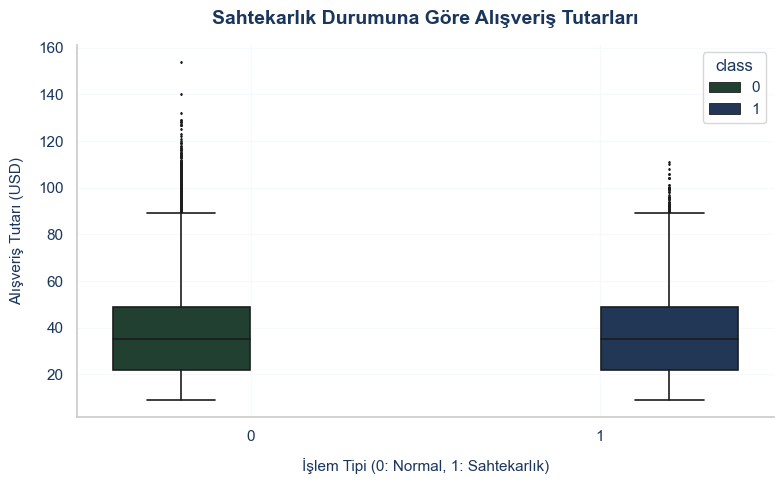

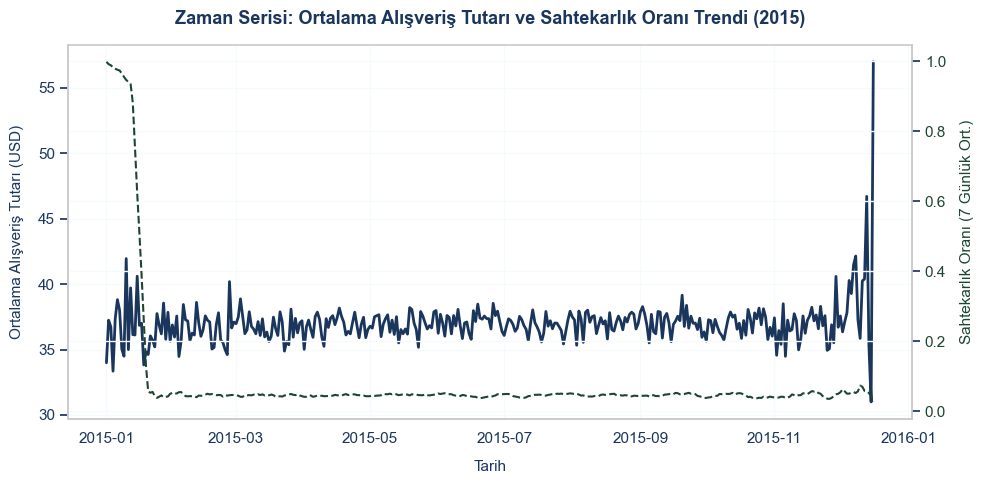

In [4]:
# Grafik 1: Sahtekarlık Durumuna Göre Alışveriş Tutarları
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_fraud, 
    x='class', 
    y='purchase_value', 
    hue='class',
    palette={0: '#1C4532', 1: '#1A365D'}, 
    ax=ax,
    fliersize=1,
    linewidth=1.2
)
ax.set_title("Sahtekarlık Durumuna Göre Alışveriş Tutarları", fontsize=14, pad=15, fontweight='bold', color='#1A365D')
ax.set_xlabel("İşlem Tipi (0: Normal, 1: Sahtekarlık)", fontsize=11, labelpad=10, color='#1A365D')
ax.set_ylabel("Alışveriş Tutarı (USD)", fontsize=11, labelpad=10, color='#1A365D')
ax.grid(True, color="#F7FAFC", linestyle="-", linewidth=1.0)
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.savefig("eda_fraud_distribution.png", dpi=300)
plt.show()

# Grafik 2: Günlük Alışveriş Tutarı ve Sahtekarlık Oranı Trendi
df_fraud['date'] = df_fraud['purchase_time'].dt.normalize()
df_daily = df_fraud.groupby('date').agg({
    'class': 'mean',
    'purchase_value': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_daily['date'], df_daily['purchase_value'], color='#1A365D', linewidth=2.0, label='Ort. Alışveriş Tutarı')
ax1.set_xlabel('Tarih', fontsize=11, labelpad=10, color='#1A365D')
ax1.set_ylabel('Ortalama Alışveriş Tutarı (USD)', fontsize=11, labelpad=10, color='#1A365D')
ax1.tick_params(axis='y', labelcolor='#1A365D')
ax1.grid(True, color="#F7FAFC", linestyle="-", linewidth=1.0)

ax2 = ax1.twinx()
smooth_fraud = df_daily['class'].rolling(7, min_periods=1).mean()
ax2.plot(df_daily['date'], smooth_fraud, color='#1C4532', linewidth=1.5, linestyle='--', label='Sahtekarlık Oranı (7G Ort)')
ax2.set_ylabel('Sahtekarlık Oranı (7 Günlük Ort.)', fontsize=11, labelpad=10, color='#1C4532')
ax2.tick_params(axis='y', labelcolor='#1C4532')

plt.title("Zaman Serisi: Ortalama Alışveriş Tutarı ve Sahtekarlık Oranı Trendi (2015)", fontsize=13, pad=15, fontweight='bold', color='#1A365D')
sns.despine(ax=ax1, top=True, right=False)
plt.tight_layout()
plt.savefig("eda_macro_trends.png", dpi=300)
plt.show()

### Adım 4: Modelleme ve Performans Karşılaştırması
Üç farklı sınıflandırma modelini (Lojistik Regresyon, Karar Ağacı, Rastgele Orman) eğitiyoruz. Modellerin doğruluk, kesinlik, duyarlılık ve F1-Skor metriklerini karşılaştıracağız.

Lojistik Regresyon eğitiliyor...
Karar Ağacı eğitiliyor...
Rastgele Orman eğitiliyor...

Performans Metrikleri Karşılaştırması:
                     accuracy  precision     recall         f1       auc
Lojistik Regresyon  90.634761   0.000000   0.000000   0.000000  0.762900
Karar Ağacı         95.590026  99.628844  53.109101  69.284661  0.845310
Rastgele Orman      95.605908  99.946809  53.109101  69.361388  0.849727


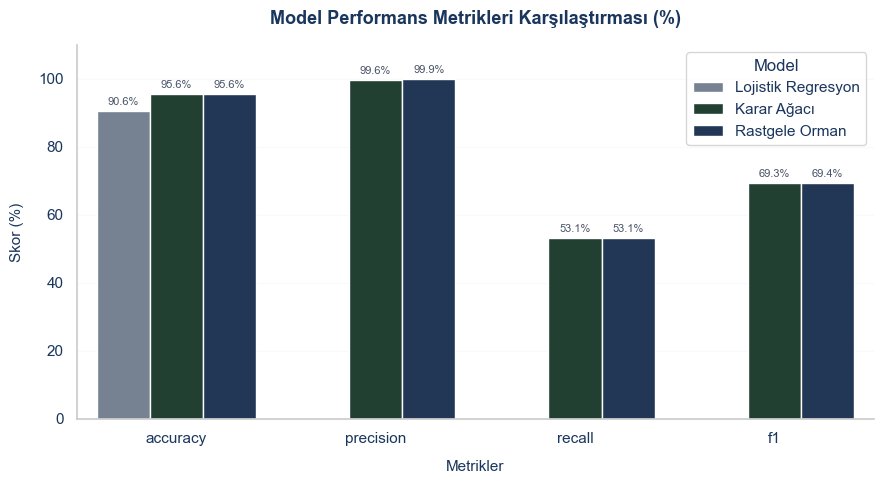

In [5]:
# Özelliklerin hazırlanması
X = df_fraud[['purchase_value', 'time_diff', 'device_user_count', 'ip_user_count', 'purchase_hour', 'purchase_day_of_week', 'source', 'browser', 'sex', 'age', 'country']].copy()
y = df_fraud['class']

# Kategorik kodlama
for col in ['source', 'browser', 'sex', 'country']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Eğitim-test bölme (%25 test, stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Modellerin eğitimi
models = {
    'Lojistik Regresyon': LogisticRegression(max_iter=1000, random_state=42),
    'Karar Ağacı': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Rastgele Orman': RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
}

metrics_dict = {}
for name, model in models.items():
    print(f"{name} eğitiliyor...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics_dict[name] = {
        'accuracy': accuracy_score(y_test, y_pred) * 100,
        'precision': precision_score(y_test, y_pred, zero_division=0) * 100,
        'recall': recall_score(y_test, y_pred) * 100,
        'f1': f1_score(y_test, y_pred) * 100,
        'auc': roc_auc_score(y_test, y_prob)
    }

df_metrics = pd.DataFrame(metrics_dict).T
print("\nPerformans Metrikleri Karşılaştırması:")
print(df_metrics.to_string())

# Barplot Karşılaştırması
df_plot = df_metrics.drop(columns=['auc']).reset_index().rename(columns={'index': 'Model'})
df_melted = pd.melt(df_plot, id_vars='Model', var_name='Metrik', value_name='Değer')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=df_melted,
    x='Metrik',
    y='Değer',
    hue='Model',
    palette={'Lojistik Regresyon': '#718096', 'Karar Ağacı': '#1C4532', 'Rastgele Orman': '#1A365D'},
    ax=ax
)
ax.set_title("Model Performans Metrikleri Karşılaştırması (%)", fontsize=13, pad=15, fontweight='bold', color='#1A365D')
ax.set_xlabel("Metrikler", fontsize=11, labelpad=10, color='#1A365D')
ax.set_ylabel("Skor (%)", fontsize=11, labelpad=10, color='#1A365D')
ax.set_ylim(0, 110)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, color='#4A5568')
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()

### Adım 5: Açıklanabilir Yapay Zeka (XAI) - SHAP Analizi
Random Forest modelinin kararlarını şeffaflaştırmak amacıyla SHAP öznitelik önem analizini gerçekleştiriyoruz.

The figure layout has changed to tight


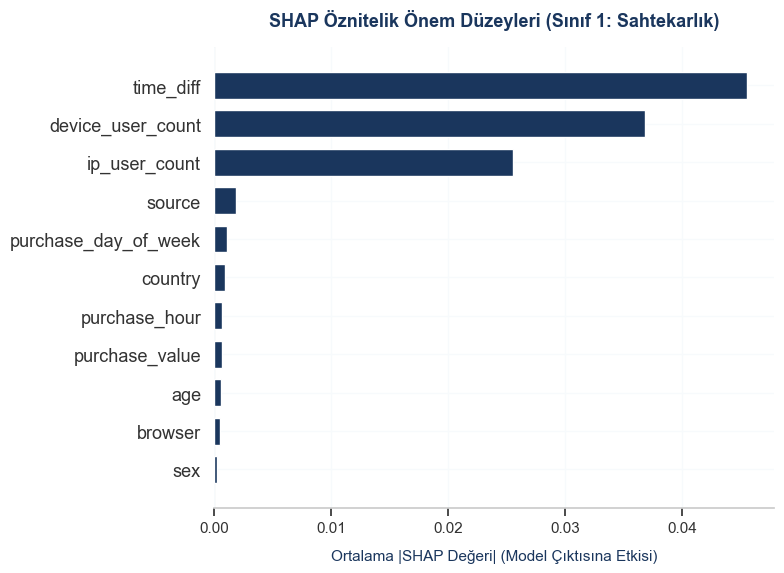

In [6]:
explainer = shap.TreeExplainer(models['Rastgele Orman'])
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_vals_class1 = shap_values[:, :, 1]
else:
    shap_vals_class1 = shap_values

plt.figure(figsize=(8, 4.5))
shap.summary_plot(
    shap_vals_class1, 
    X_test_sample, 
    plot_type="bar", 
    color="#1A365D",
    show=False
)
plt.title("SHAP Öznitelik Önem Düzeyleri (Sınıf 1: Sahtekarlık)", fontsize=13, fontweight='bold', pad=15, color='#1A365D')
plt.xlabel("Ortalama |SHAP Değeri| (Model Çıktısına Etkisi)", fontsize=11, labelpad=10, color='#1A365D')
plt.grid(True, color="#F7FAFC", linestyle="-", linewidth=1.0)
plt.tight_layout()
plt.savefig("shap_explanation.png", dpi=300)
plt.show()

### Adım 6: Maliyet-Duyarlı Karar Optimizasyonu ve ROI Simülasyonu
Farklı karar olasılık eşiklerini tarayarak işletmenin operasyonel maliyetini en aza indiren en kârlı noktayı (optimal threshold) belirliyoruz.

Optimal Karar Eşiği (Threshold): 0.21
Model Olmadığında Toplam Maliyet: 236126.00 USD
Optimal Eşikteki Toplam Maliyet: 116193.00 USD
Model Sayesinde Net Tasarruf: 119933.00 USD
Net Yatırım Getirisi (ROI): %50.79


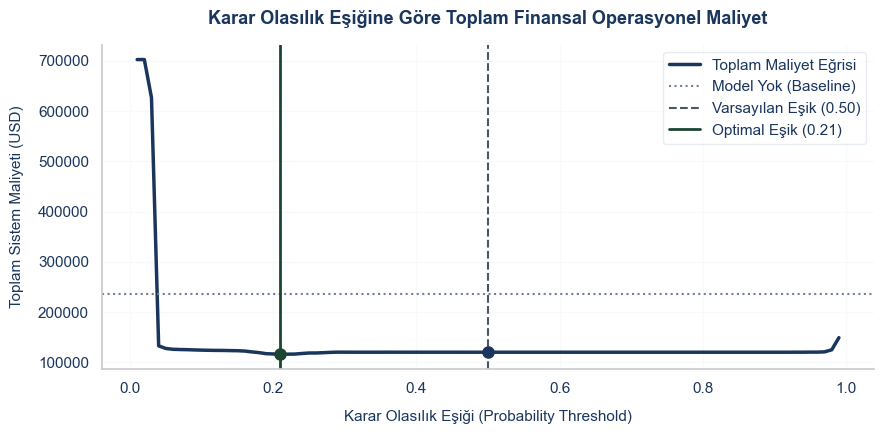

In [7]:
y_pred_prob = models['Rastgele Orman'].predict_proba(X_test)[:, 1]
amount_test = X_test['purchase_value'].values
thresholds = np.linspace(0.01, 0.99, 99)
costs = []

# Operasyonel birim maliyetler (USD)
cost_fp_unit = 20.0  # False Positive (Müşteri engelleme kaybı)
cost_fn_penalty = 30.0  # False Negative (Kaçırılan sahtekarlık cezası + işlem tutarı)
cost_tp_unit = 5.0  # True Positive (Güvenlik kontrol maliyeti)

for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)
    
    tp = (y_test == 1) & (y_pred == 1)
    fn = (y_test == 1) & (y_pred == 0)
    fp = (y_test == 0) & (y_pred == 1)
    
    c_tp = tp.sum() * cost_tp_unit
    c_fn = np.sum(amount_test[fn] + cost_fn_penalty)
    c_fp = fp.sum() * cost_fp_unit
    
    total_cost = c_tp + c_fn + c_fp
    costs.append(total_cost)

costs = np.array(costs)

# Baselines
cost_no_model = np.sum(amount_test[y_test == 1] + cost_fn_penalty)
y_pred_default = (y_pred_prob >= 0.50).astype(int)
cost_default = (
    ((y_test == 1) & (y_pred_default == 1)).sum() * cost_tp_unit +
    np.sum(amount_test[(y_test == 1) & (y_pred_default == 0)] + cost_fn_penalty) +
    ((y_test == 0) & (y_pred_default == 1)).sum() * cost_fp_unit
)

opt_idx = np.argmin(costs)
opt_threshold = thresholds[opt_idx]
opt_cost = costs[opt_idx]
savings = cost_no_model - opt_cost
roi = (savings / cost_no_model) * 100

print(f"Optimal Karar Eşiği (Threshold): {opt_threshold:.2f}")
print(f"Model Olmadığında Toplam Maliyet: {cost_no_model:.2f} USD")
print(f"Optimal Eşikteki Toplam Maliyet: {opt_cost:.2f} USD")
print(f"Model Sayesinde Net Tasarruf: {savings:.2f} USD")
print(f"Net Yatırım Getirisi (ROI): %{roi:.2f}")

# Maliyet Eğrisi Çizimi
plt.figure(figsize=(9, 4.5))
plt.plot(thresholds, costs, color='#1A365D', linewidth=2.5, label='Toplam Maliyet Eğrisi')
plt.axhline(y=cost_no_model, color='#718096', linestyle=':', label='Model Yok (Baseline)')
plt.axvline(x=0.50, color='#4A5568', linestyle='--', label='Varsayılan Eşik (0.50)')
plt.axvline(x=opt_threshold, color='#1C4532', linestyle='-', linewidth=2.0, label=f'Optimal Eşik ({opt_threshold:.2f})')
plt.plot(opt_threshold, opt_cost, marker='o', color='#1C4532', markersize=8)
plt.plot(0.50, cost_default, marker='o', color='#1A365D', markersize=8)
plt.title("Karar Olasılık Eşiğine Göre Toplam Finansal Operasyonel Maliyet", fontsize=13, fontweight='bold', pad=15, color='#1A365D')
plt.xlabel("Karar Olasılık Eşiği (Probability Threshold)", fontsize=11, labelpad=10, color='#1A365D')
plt.ylabel("Toplam Sistem Maliyeti (USD)", fontsize=11, labelpad=10, color='#1A365D')
plt.legend(frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0')
plt.grid(True, color="#F7FAFC", linestyle="-", linewidth=1.0)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.savefig("cost_simulation_curve.png", dpi=300)
plt.show()